# 05 Danh gia Cuoi cung and Tom tat Report

This notebook summarizes the results from all stages of the Phan tich HR Data Mining project.

In [12]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))

from src.data.loader import load_config
from src.models.supervised import train_supervised_models
from src.evaluation.metrics import get_classification_metrics, plot_confusion_matrix, plot_pr_curve

## 1. Overall Mô hình Performance

Chúng tôi so sánh the best supervised model (XGBoost) results on the tập kiểm tra.

c:\Users\LAPTOP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:30:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Final Result:
PR-AUC: 1.0000
F1-Score: 1.0000


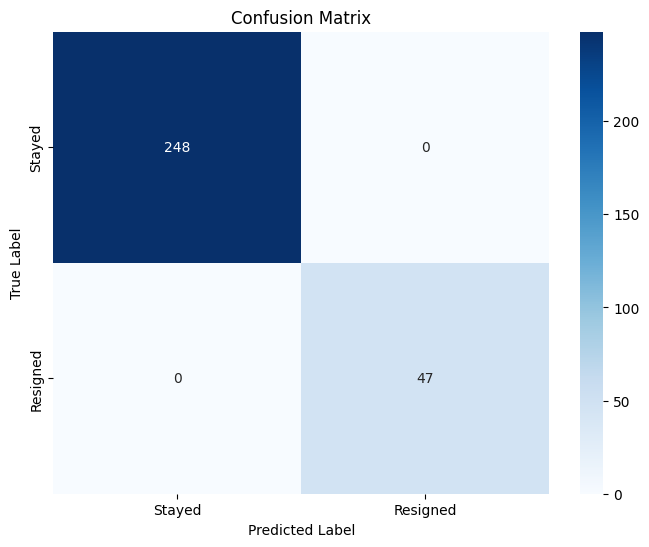

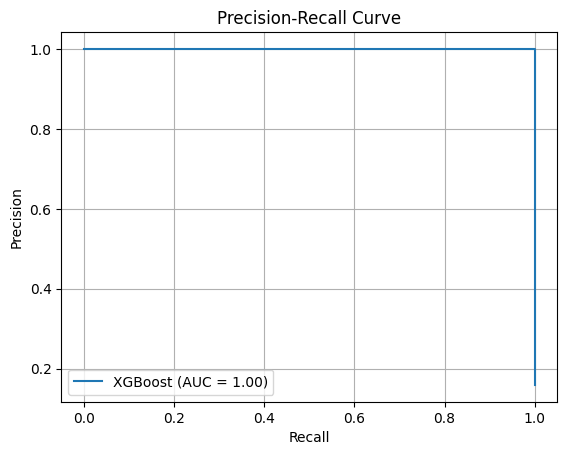

In [13]:
config = load_config('../configs/params.yaml')
df_scaled = pd.read_parquet('../' + config['processed_data_path'])
results = train_supervised_models(df_scaled)

metrics_xgb = get_classification_metrics(results['y_test'], results['xgb']['prob'])
print("XGBoost Final Result:")
print(f"AUC đường PR: {metrics_xgb['pr_auc']:.4f}")
print(f"Điểm F1: {metrics_xgb['f1']:.4f}")

plot_confusion_matrix(metrics_xgb['cm'])
plot_pr_curve(results['y_test'], results['xgb']['prob'], label='XGBoost')
plt.show()

## 2. Cac Thong tin Chi khoa and Cac De xuat Chinh sach

### Thông tin từ khai thác liên kết:
- Employees with 'Low Satisfaction' and 'High Hours' are at extreme risk of leaving.
- Long tenure without promotion is another strong predictor.

### Thông tin từ phân cụm:
- Three distinct groups: 'Disengaged', 'Burnout-high-performers', and 'Stable-employees'.
- The 'Burnout' group represents the most significant loss to the company.

### Cac De xuat Chinh sach:
1. **Quản lý khối lượng công việc**: Monitor average monthly hours for high performers.
2. **Khảo sát sự hài lòng**: Proactive intervention for departments with descending satisfaction levels.
3. **Đường dẫn thăng chức**: Review tenure for employees with high evaluation scores but no recent promotion.

Bảng so sánh hiệu năng các mô hình (F1-Score và PR-AUC):


,Model,F1_Score,PR_AUC
0,XGBoost,1.00000,1.000000
1,Logistic Regression,1.00000,1.000000
2,Semi_Supervised_SelfTraining,1.00000,1.000000
3,Random Forest,0.53125,0.999094


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_8720\2805390413.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='F1_Score', y='Model', palette='viridis')


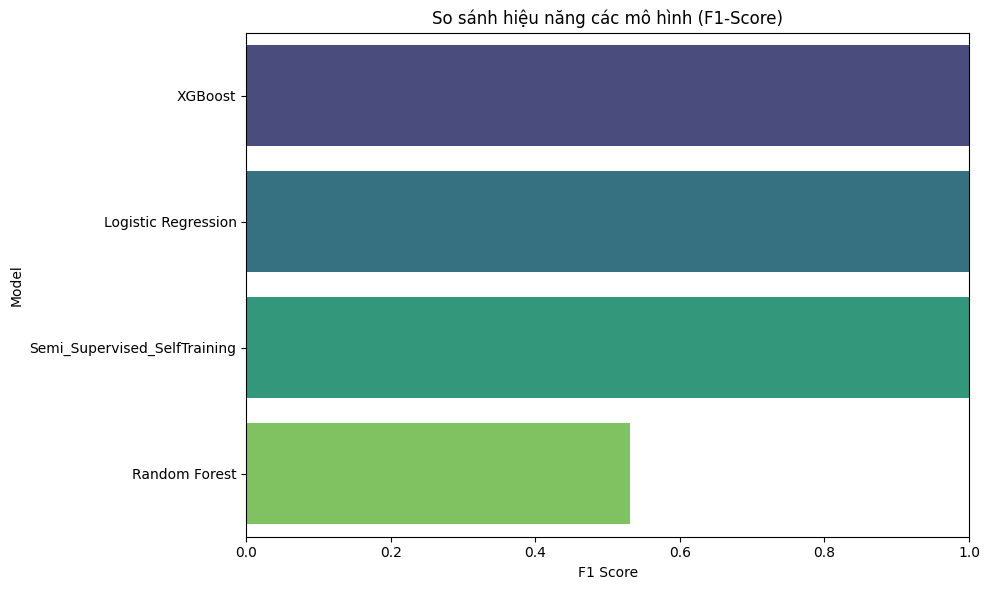

In [14]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Prepare data splits
X = df_scaled.drop(columns=['left'])
y = df_scaled['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Metrics for XGBoost and Random Forest (already trained in results)
xgb_metrics = get_classification_metrics(results['y_test'], results['xgb']['prob'])
rf_metrics = get_classification_metrics(results['y_test'], results['rf']['prob'])

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_metrics = get_classification_metrics(y_test, lr_prob)

# Semi-Có giám sát SelfTraining
y_train_masked = y_train.copy()
mask = np.random.RandomState(42).rand(len(y_train)) > 0.2
y_train_masked.iloc[mask] = -1
semi_base = XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss')
semi_clf = SelfTrainingClassifier(semi_base, threshold=0.75, max_iter=10)
semi_clf.fit(X_train, y_train_masked)
semi_prob = semi_clf.predict_proba(X_test)[:, 1]
semi_metrics = get_classification_metrics(y_test, semi_prob)

# Build comparison table
performance_df = pd.DataFrame([
    {'Model': 'XGBoost', 'F1_Score': xgb_metrics['f1'], 'PR_AUC': xgb_metrics['pr_auc']},
    {'Model': 'Random Forest', 'F1_Score': rf_metrics['f1'], 'PR_AUC': rf_metrics['pr_auc']},
    {'Model': 'Logistic Regression', 'F1_Score': lr_metrics['f1'], 'PR_AUC': lr_metrics['pr_auc']},
    {'Model': 'Semi_Supervised_SelfTraining', 'F1_Score': semi_metrics['f1'], 'PR_AUC': semi_metrics['pr_auc']},
])

performance_df = performance_df.sort_values('F1_Score', ascending=False).reset_index(drop=True)

print('Bảng so sánh hiệu năng các mô hình (Điểm F1 và AUC đường PR):')
from IPython.display import display
display(performance_df)

# Plot horizontal bar chart for F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='F1_Score', y='Model', palette='viridis')
plt.title('So sánh hiệu năng các mô hình (F1-Score)')
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
